In [52]:
import pandas as pd

In [53]:
import sqlite3 as bd

In [54]:
conn =bd.connect("data/ventas_2025.db")

In [55]:
facturas =pd.read_sql("SELECT * FROM facturas", conn)
items=pd.read_sql("SELECT * FROM items", conn)

In [56]:
facturas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   factura_id  1000 non-null   str    
 1   cliente     1000 non-null   str    
 2   fecha       1000 non-null   str    
 3   subtotal    1000 non-null   float64
 4   iva         1000 non-null   float64
 5   total       1000 non-null   float64
 6   valida      1000 non-null   int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 54.8 KB


In [57]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 2939 entries, 0 to 2938
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   factura_id  2939 non-null   str    
 1   producto    2939 non-null   str    
 2   cantidad    2939 non-null   int64  
 3   total       2939 non-null   float64
 4   item_id     2939 non-null   int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 114.9 KB


In [58]:
facturas.isnull().sum()


factura_id    0
cliente       0
fecha         0
subtotal      0
iva           0
total         0
valida        0
dtype: int64

In [59]:
items.isnull().sum()

factura_id    0
producto      0
cantidad      0
total         0
item_id       0
dtype: int64

In [67]:
facturas.duplicated().sum()

np.int64(0)

In [68]:
items.duplicated().sum()

np.int64(0)

In [71]:
items_grouped = items.groupby("factura_id")["total"].sum().reset_index()
items_grouped.head()

,factura_id,total
0,F25-0001,9946.41
1,F25-0002,12750.00
2,F25-0003,25.98
3,F25-0004,281.94
4,F25-0005,8988.00


In [93]:
merged = facturas.merge(items_grouped, on="factura_id", how="left")
merged.head()

,factura_id,cliente,fecha,subtotal,iva,total_x,valida,total_y
0,F25-0001,Logística Global,2025-05-04,9946.41,1889.82,11836.23,1,9946.41
1,F25-0002,Inversiones ABC,2025-05-02,12750.00,2422.50,15172.50,1,12750.00
2,F25-0003,Tienda Don Pepe,2025-07-20,25.98,4.94,30.92,1,25.98
3,F25-0004,Tienda Don Pepe,2025-02-14,281.94,53.57,335.51,1,281.94
4,F25-0005,Tech Solutions,2025-09-11,8988.00,1707.72,10695.72,1,8988.00


In [73]:
merged["diff"] = merged["subtotal"] - merged["total_y"]
merged.head()

,factura_id,cliente,fecha,subtotal,iva,total_x,valida,total_y,diff
0,F25-0001,Logística Global,2025-05-04 00:00:00,9946.41,1889.82,11836.23,1,9946.41,0.0
1,F25-0002,Inversiones ABC,2025-05-02 00:00:00,12750.00,2422.50,15172.50,1,12750.00,0.0
2,F25-0003,Tienda Don Pepe,2025-07-20 00:00:00,25.98,4.94,30.92,1,25.98,0.0
3,F25-0004,Tienda Don Pepe,2025-02-14 00:00:00,281.94,53.57,335.51,1,281.94,0.0
4,F25-0005,Tech Solutions,2025-09-11 00:00:00,8988.00,1707.72,10695.72,1,8988.00,0.0


In [74]:
merged["diff"].describe()

count    1.000000e+03
mean     4.521006e+01
std      4.577259e+02
min     -3.637979e-12
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.400000e+03
Name: diff, dtype: float64

In [76]:
facturas['fecha'] = pd.to_datetime(facturas['fecha'])

In [77]:
bi_facturas = merged.drop(columns=['total_x', 'diff']).copy()

In [78]:
bi_facturas.to_sql("facturas_clean", conn, if_exists="replace", index=False)

1000

In [80]:
bi_facturas.to_csv("data/facturas_para_looker.csv", index=False)

In [83]:
import pandas as pd
import numpy as np


In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [96]:
items_grouped = items.groupby("factura_id")["total"].sum().reset_index()

merged = facturas.merge(items_grouped, on="factura_id", how="left")

merged["diff"] = merged["subtotal"] - merged["total_y"]

merged["diff"].describe()

count    1.000000e+03
mean     4.521006e+01
std      4.577259e+02
min     -3.637979e-12
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.400000e+03
Name: diff, dtype: float64

In [106]:
errores = merged[merged["diff"].abs() > 1]  # ignoramos decimales pequeños
print(errores)

    factura_id            cliente      fecha  subtotal      iva   total_x  \
14    F25-0015    Tienda Don Pepe 2025-01-24   3438.00   653.22   4091.22   
23    F25-0024   Logística Global 2025-02-10   1500.00   285.00   1785.00   
55    F25-0056    Inversiones ABC 2025-11-26    526.71   100.07    626.78   
70    F25-0071  Servicios Express 2025-08-08  18643.92  3542.34  22186.26   
153   F25-0154   Logística Global 2025-10-05   2042.94   388.16   2431.10   
170   F25-0171    Inversiones ABC 2025-07-28   7729.50  1468.61   9198.10   
198   F25-0199   Logística Global 2025-03-20    585.87   111.32    697.19   
205   F25-0206    Tienda Don Pepe 2025-01-30    625.98   118.94    744.92   
206   F25-0207    Inversiones ABC 2025-10-25    181.86    34.55    216.41   
240   F25-0241    Tienda Don Pepe 2025-05-22    526.44   100.02    626.46   
264   F25-0265     Tech Solutions 2025-07-10  13847.94  2631.11  16479.05   
268   F25-0269  Servicios Express 2025-05-23   1974.00   375.06   2349.06   

In [107]:
len(errores)

54

In [108]:
errores.sort_values(by="diff", ascending=False).head(10)

,factura_id,cliente,fecha,subtotal,iva,total_x,valida,total_y,diff
845,F25-0846,Logística Global,2025-06-21,17565.00,3337.35,20902.35,1,9165.00,8400.0
647,F25-0648,Logística Global,2025-06-23,28429.50,5401.61,33831.11,1,20029.50,8400.0
264,F25-0265,Tech Solutions,2025-07-10,13847.94,2631.11,16479.05,1,7847.94,6000.0
470,F25-0471,Logística Global,2025-09-12,7654.50,1454.36,9108.85,1,4054.50,3600.0
848,F25-0849,Servicios Express,2025-11-20,12129.90,2304.68,14434.58,1,9729.90,2400.0
170,F25-0171,Inversiones ABC,2025-07-28,7729.50,1468.61,9198.10,1,5329.50,2400.0
760,F25-0761,Tech Solutions,2025-09-25,4601.91,874.36,5476.27,1,2981.91,1620.0
818,F25-0819,Tienda Don Pepe,2025-11-16,2880.00,547.20,3427.20,1,1440.00,1440.0
752,F25-0753,Logística Global,2025-06-23,2786.91,529.51,3316.42,1,1526.91,1260.0
433,F25-0434,Tienda Don Pepe,2025-06-20,1627.50,309.23,1936.72,1,877.50,750.0


In [109]:
errores["diff"].value_counts().head(10)

diff
150.0     4
360.0     4
75.0      3
375.0     2
2400.0    2
229.5     2
405.0     2
540.0     2
51.0      2
8400.0    2
Name: count, dtype: int64

Detecté inconsistencias entre el nivel de cabecera y detalle. Al analizar la distribución de las diferencias, observé patrones repetitivos que indican pérdida sistemática de registros en la tabla de ítems. Esto afecta directamente la confiabilidad de los análisis basados en detalle.

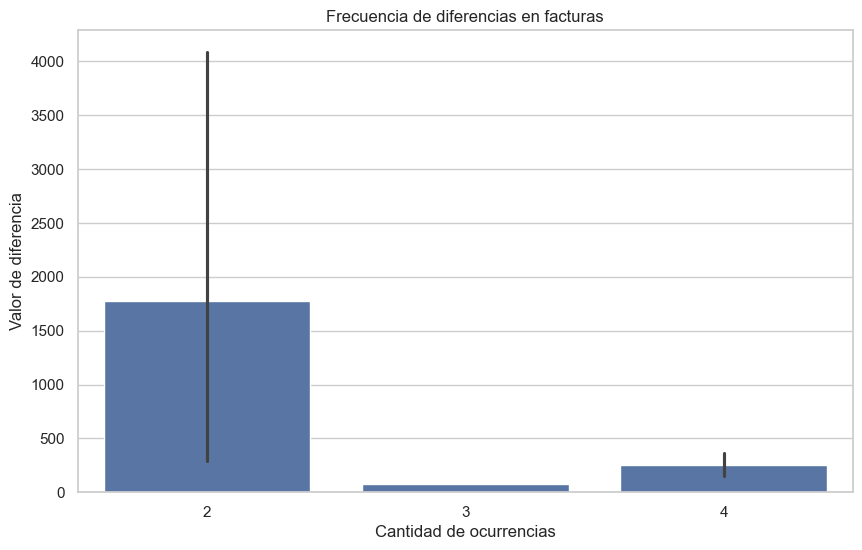

In [110]:
errores_counts = errores["diff"].value_counts().head(10)

sns.barplot(x=errores_counts.values, y=errores_counts.index)
plt.title("Frecuencia de diferencias en facturas")
plt.xlabel("Cantidad de ocurrencias")
plt.ylabel("Valor de diferencia")
plt.show()

In [97]:
total_ventas = merged["subtotal"].sum()
print(f"Ventas totales: ${total_ventas:,.0f}")

Ventas totales: $4,301,187


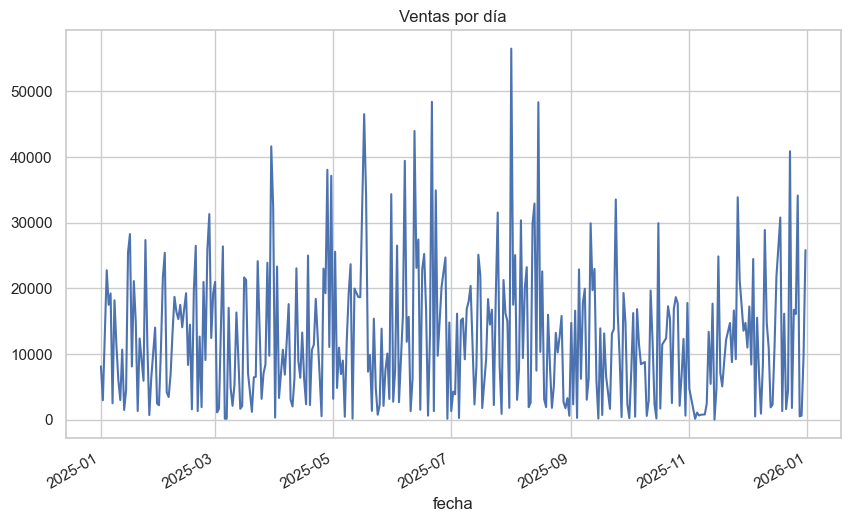

In [98]:
merged["fecha"] = pd.to_datetime(merged["fecha"])

ventas_por_dia = merged.groupby("fecha")["subtotal"].sum()

ventas_por_dia.plot(title="Ventas por día")
plt.show()

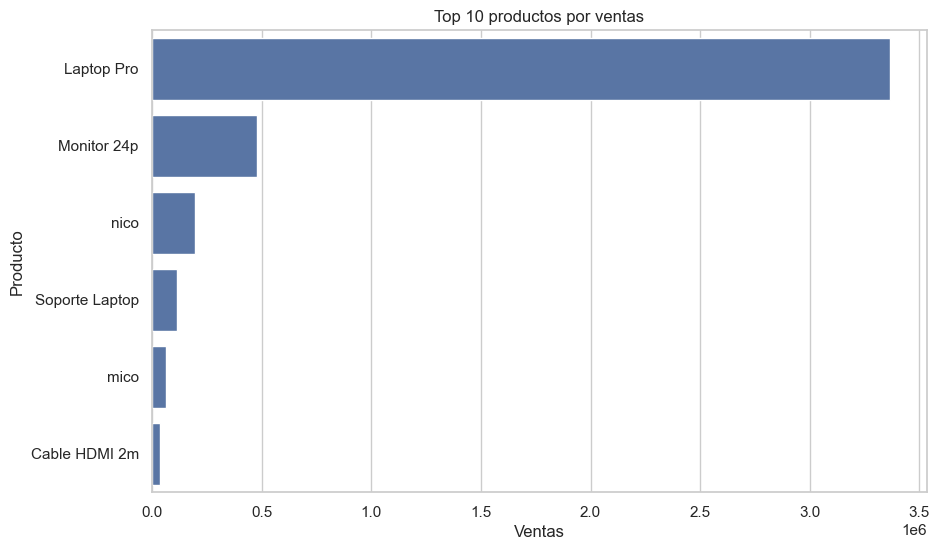

In [99]:
top_productos = items.groupby("producto")["total"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_productos.values, y=top_productos.index)
plt.title("Top 10 productos por ventas")
plt.xlabel("Ventas")
plt.ylabel("Producto")
plt.show()

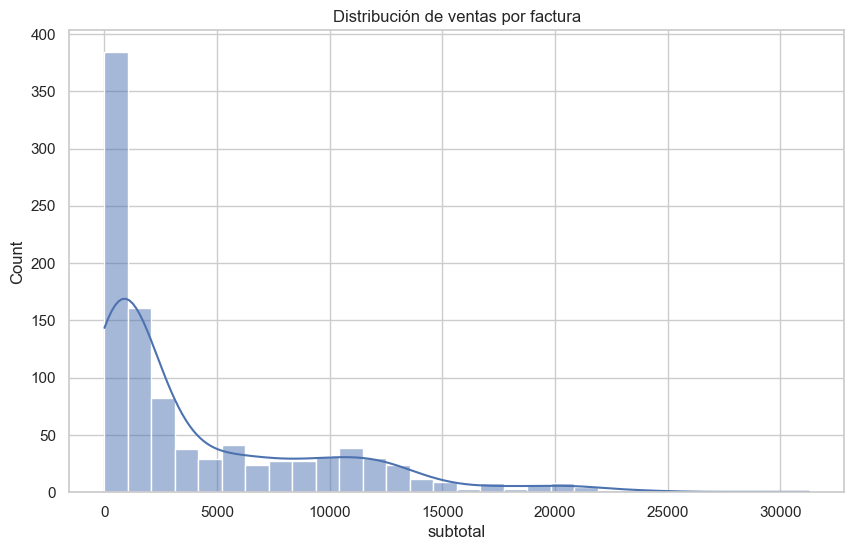

In [100]:
sns.histplot(merged["subtotal"], bins=30, kde=True)
plt.title("Distribución de ventas por factura")
plt.show()

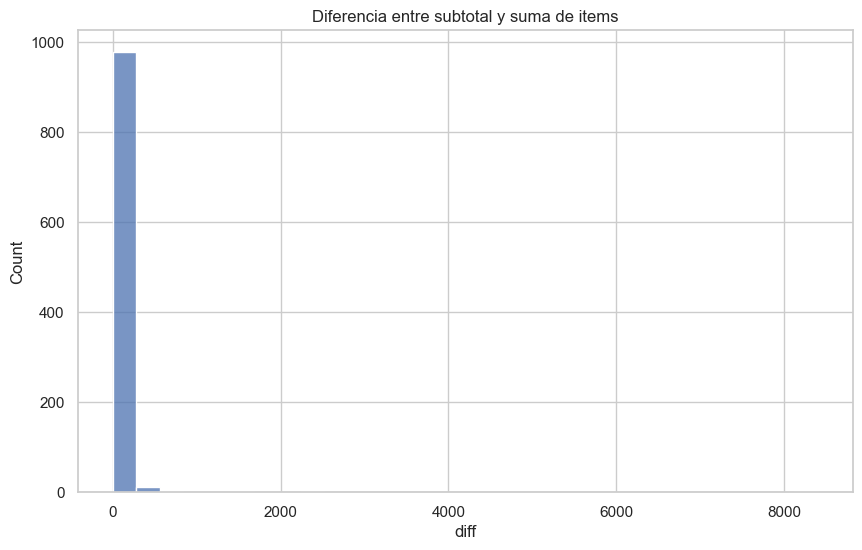

In [102]:
sns.histplot(merged["diff"], bins=30)
plt.title("Diferencia entre subtotal y suma de items")
plt.show()

In [103]:
ticket_promedio = merged["subtotal"].mean()
print(f"Ticket promedio: ${ticket_promedio:,.0f}")

Ticket promedio: $4,301


In [104]:
print(merged.columns)

Index(['factura_id', 'cliente', 'fecha', 'subtotal', 'iva', 'total_x',
       'valida', 'total_y', 'diff'],
      dtype='str')


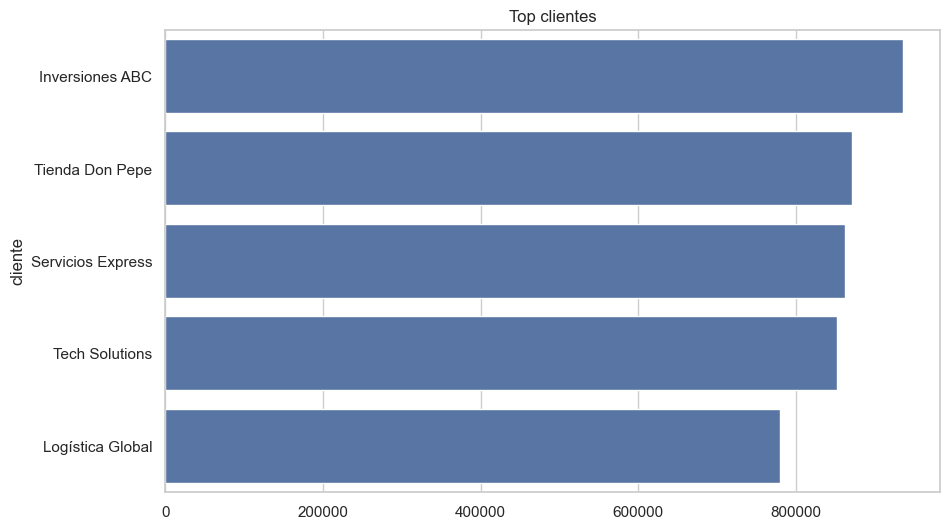

In [105]:
top_clientes = merged.groupby("cliente")["subtotal"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_clientes.values, y=top_clientes.index)
plt.title("Top clientes")
plt.show()

In [111]:
merged.to_csv("ventas_limpias.csv", index=False)